In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [405]:
import keras
from keras.layers import Flatten, Dense,GRU, LSTM, RNN
from keras.models import Sequential
from tensorflow.keras import layers
from keras.layers import Dropout
from tensorflow.keras import regularizers

In [2]:
ethereum = pd.read_csv('/home/pavel/Загрузки/Telegram Desktop/ethereum-historical-data.csv')
solana = pd.read_csv('/home/pavel/Загрузки/Telegram Desktop/solana-historical-data (4).csv')
tether = pd.read_csv('/home/pavel/Загрузки/Telegram Desktop/tether-historical-data (2).csv')

In [67]:
bitcoin = pd.read_csv('/home/pavel/Загрузки/Telegram Desktop/btcusd_1-min_data.csv')

In [68]:
bitcoin['Timestamp'] = pd.to_datetime(bitcoin['Timestamp'] ,unit = 's')

In [69]:
bitcoin['year'] = bitcoin['Timestamp'].dt.year
bitcoin['month'] = bitcoin['Timestamp'].dt.month
bitcoin['day'] = bitcoin['Timestamp'].dt.day
bitcoin['hour'] = bitcoin['Timestamp'].dt.hour
bitcoin['minute'] = bitcoin['Timestamp'].dt.minute

In [70]:
day = bitcoin['day']
month = bitcoin['month']
year = bitcoin['year']
hour = bitcoin['hour']
minute = bitcoin['minute']

In [72]:
bitcoin = bitcoin[(year >= 2022) & (year <= 2025) & (day >= 1) & (month >= 1) & (hour == 0) & (minute == 0)]

In [77]:
bitcoin = bitcoin[(bitcoin['Timestamp'] >= '2022-06-10') & (bitcoin['Timestamp'] <= '2025-06-09')]

In [82]:
bitcoin = bitcoin.drop(columns = ['year','month', 'day'])

In [6]:
ethereum = ethereum.dropna()
solana = solana.dropna()
tether = tether.dropna()

In [8]:
ethereum.columns
col= ['Открытие','Макс', 'Мин', 'Средняя', 'Закрыть','Объём','Капитализ.']

In [84]:
bitcoin = bitcoin.rename(columns = {'Timestamp' : 'Дата', 'Open' : 'Открытие', 'Volume' : 'Объём' })

In [10]:
def conv_str_to_float(df, columns):
    dataset = df.copy()
    for col in columns:
        dataset[col] = dataset[col].str.replace('$', '').str.replace(',', '').astype(float)
    return dataset

In [11]:
ethereum = conv_str_to_float(ethereum, col)
solana = conv_str_to_float(solana, col)
tether = conv_str_to_float(tether ,col)

In [62]:
ethereum['Дата'] = pd.to_datetime(ethereum['Дата'])

In [63]:
ethereum['year'] = ethereum['Дата'].dt.year
ethereum['month'] = ethereum['Дата'].dt.month
ethereum['day'] = ethereum['Дата'].dt.day

In [15]:
ethereum = ethereum.sort_values('Дата')
solana = solana.sort_values('Дата')
tether = tether.sort_values('Дата')

In [89]:
ethereum.columns

Index(['Дата', 'Открытие', 'Макс', 'Мин', 'Средняя', 'Закрыть', 'Изм.',
       'Объём', 'Изм. Объема', 'Капитализ.', 'Изм. Капитализ.'],
      dtype='object')

In [90]:
drop_columns = ['Макс', 'Мин', 'Средняя', 'Закрыть', 'Изм.','Изм. Объема', 'Капитализ.', 'Изм. Капитализ.']
ethereum = ethereum.drop(columns = drop_columns)
solana = solana.drop(columns = drop_columns)
tether = tether.drop(columns = drop_columns)

In [94]:
bitcoin = bitcoin.drop(columns = ['High', 'Low', 'Close'])

In [132]:
eth = ethereum.copy()
soln = solana.copy()
teth = tether.copy()
btc = bitcoin.copy()

In [133]:
cel = math.pow(10, 9)
eth['Объём'] = eth['Объём'] / cel
soln['Объём'] = soln['Объём'] / cel
teth['Объём'] = teth['Объём'] / math.pow(10, 10)

In [134]:
eth = eth.reset_index(drop = True)
soln = soln.reset_index(drop = True)
teth = teth.reset_index(drop = True)
btc = btc.reset_index(drop = True)

In [175]:
def adfuller_test(dataset):
    for feature in dataset.columns:

        name_feature = dataset[feature].name
        result = adfuller(dataset[feature])
        print(f'Произведен тест Дики Фуллера Признака : {name_feature}')
        print('Результат теста:')
        if result[1] > 0.05 :
            print('Ряд не стационарен,нужно делать дифференцирование')
        else:
            print('Ряд стационарен, дифференцирование не нужно')
        print('-' * 38)

In [146]:
eth.columns

Index(['Дата', 'Открытие', 'Объём'], dtype='object')

In [147]:
eth = eth.rename(columns = {'Открытие' : 'eth_open', 'Объём' : 'eth_volumne' })
soln = soln.rename(columns = {'Открытие' : 'soln_open', 'Объём' : 'soln_volumne' })
btc = btc.rename(columns = {'Открытие' : 'btc_open', 'Объём' : 'btc_volumne' })
teth = teth.rename(columns = {'Открытие' : 'teth_open', 'Объём' : 'teth_volumne' })

In [162]:
eth = eth.drop(columns = 'Дата')
soln = soln.drop(columns = 'Дата')
teth = teth.drop(columns = 'Дата')

In [170]:
moneti = btc.copy()

In [171]:
moneti = pd.concat([moneti, eth, soln, teth], axis = 1)

In [178]:
adfuller_test(moneti)

Произведен тест Дики Фуллера Признака : Дата
Результат теста:
Ряд не стационарен,нужно делать дифференцирование
--------------------------------------
Произведен тест Дики Фуллера Признака : btc_open
Результат теста:
Ряд не стационарен,нужно делать дифференцирование
--------------------------------------
Произведен тест Дики Фуллера Признака : btc_volumne
Результат теста:
Ряд стационарен, дифференцирование не нужно
--------------------------------------
Произведен тест Дики Фуллера Признака : eth_open
Результат теста:
Ряд не стационарен,нужно делать дифференцирование
--------------------------------------
Произведен тест Дики Фуллера Признака : eth_volumne
Результат теста:
Ряд стационарен, дифференцирование не нужно
--------------------------------------
Произведен тест Дики Фуллера Признака : soln_open
Результат теста:
Ряд не стационарен,нужно делать дифференцирование
--------------------------------------
Произведен тест Дики Фуллера Признака : soln_volumne
Результат теста:
Ряд стаци

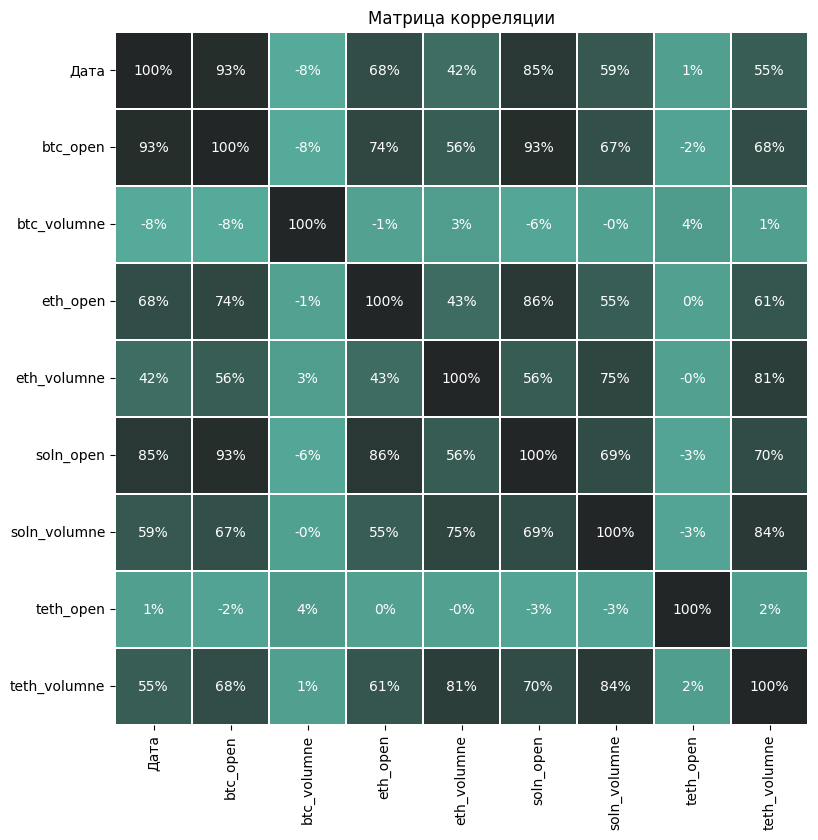

In [183]:
plt.figure(figsize = (9,9))
sns.heatmap(moneti.corr(),
            xticklabels = moneti.corr().columns,
            yticklabels = moneti.corr().columns,
            annot = True,
            fmt = '.0%',
            square = True,
            linewidth = 0.1,
            cmap = sns.color_palette("dark:#5A9_r", as_cmap=True),
            cbar = False
)
plt.title('Матрица корреляции')
plt.show()

In [184]:
birge = moneti.copy()

In [200]:
birge = birge.drop(columns = ['btc_volumne', 'eth_volumne', 'soln_volumne', 'teth_volumne'])

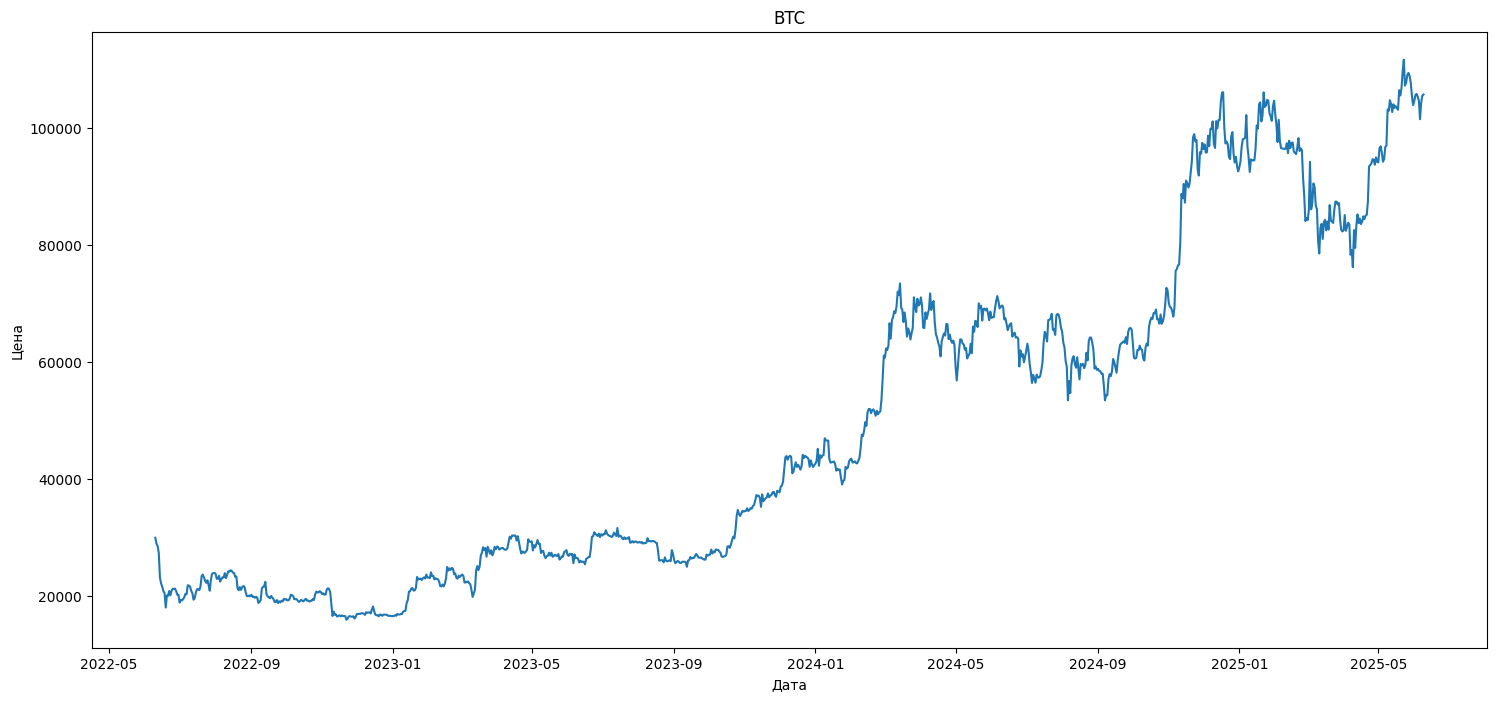

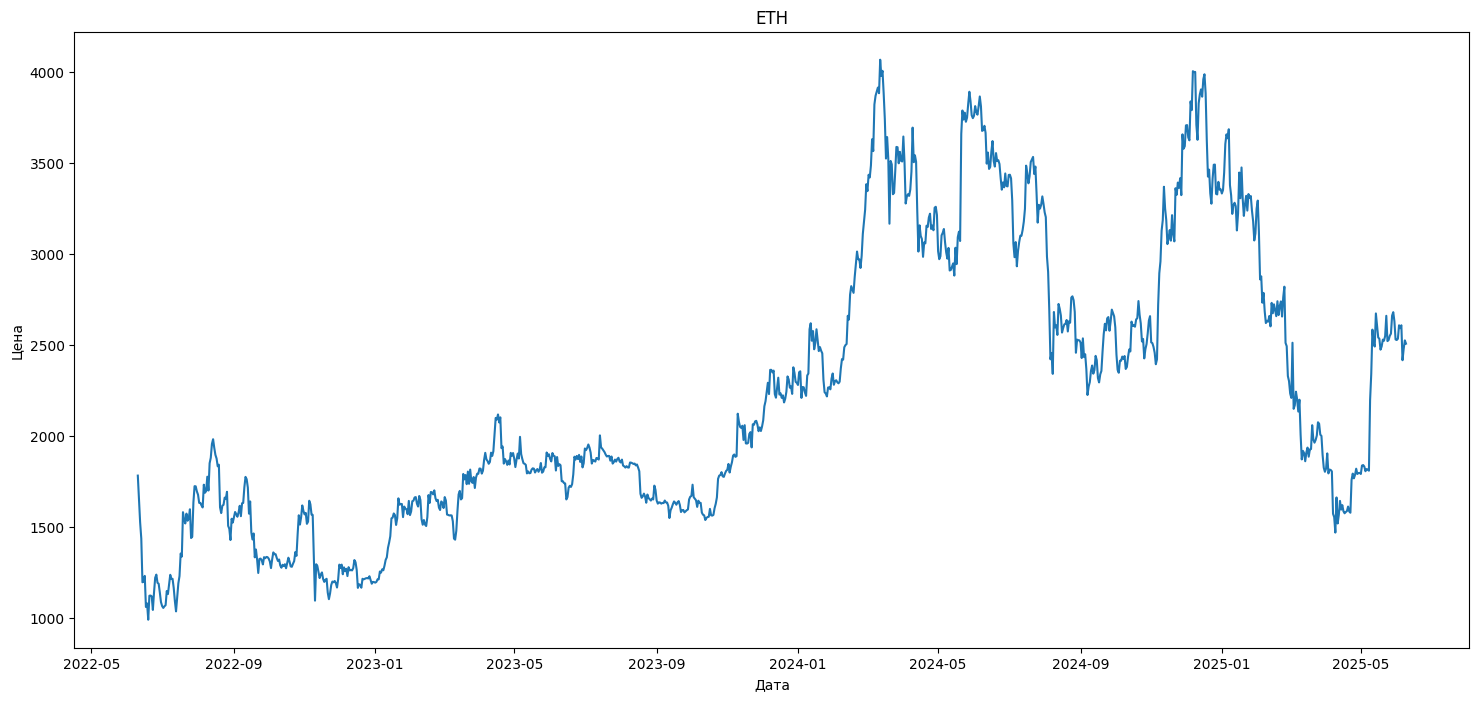

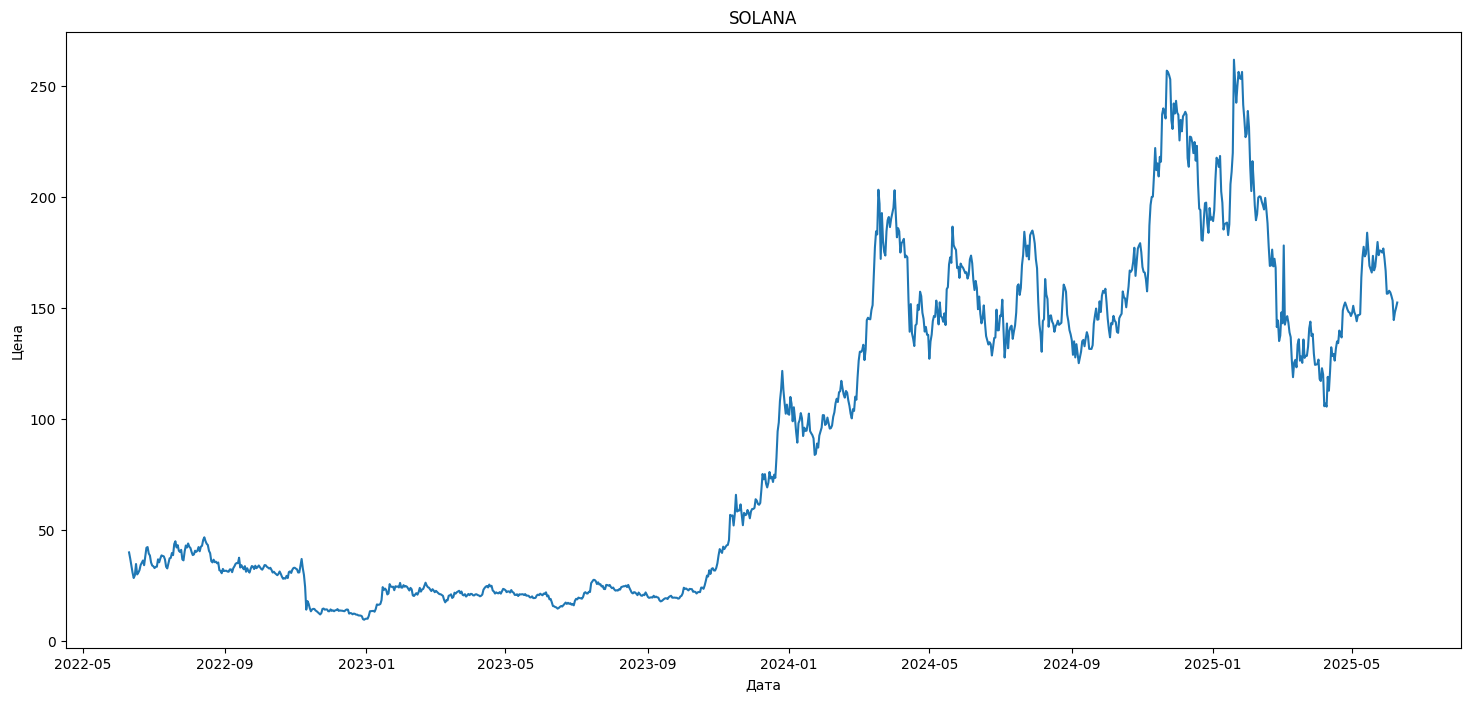

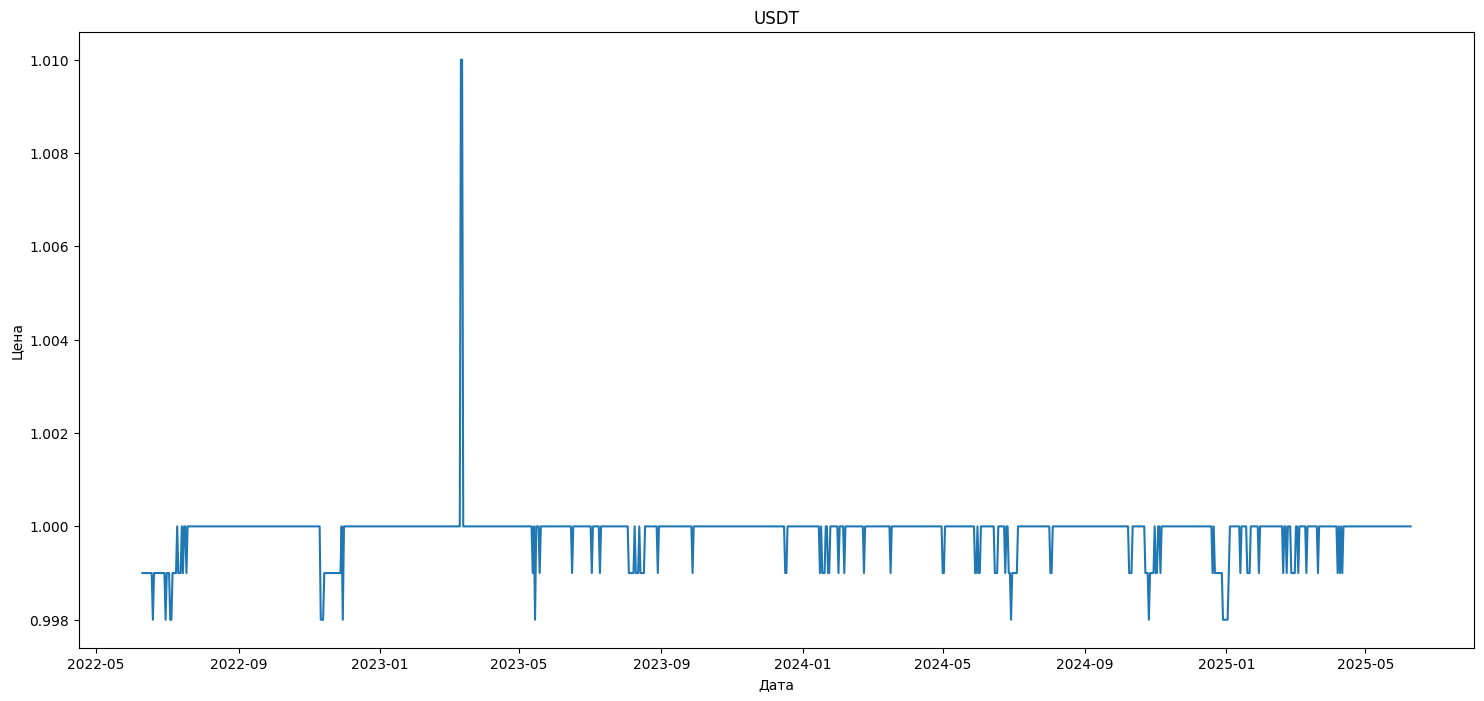

In [724]:
plt.figure(figsize = (18, 8))
plt.plot(birge['Дата'], birge[['btc_open']])
plt.title('BTC')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.show()
plt.figure(figsize = (18, 8))
plt.plot(birge['Дата'], birge[['eth_open']])
plt.title('ETH')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.show()
plt.figure(figsize = (18, 8))
plt.plot(birge['Дата'], birge[['soln_open']])
plt.title('SOLANA')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.show()
plt.figure(figsize = (18, 8))
plt.plot(birge['Дата'], birge[['teth_open']])
plt.title('USDT')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.show()


In [438]:
new_birge = birge.copy()

In [439]:
date = new_birge.columns[0]
new_birge = new_birge.set_index(date)

In [440]:
new_birge

,btc_open,eth_open,soln_open,teth_open
Дата,,,,
2022-06-10,29975.75,1784.0,39.85,0.999
2022-06-11,28951.83,1658.0,37.06,0.999
2022-06-12,28571.75,1527.0,33.86,0.999
2022-06-13,27383.72,1438.0,30.77,0.999
2022-06-14,23147.74,1198.0,28.32,0.999
...,...,...,...,...
2025-06-05,104734.00,2610.0,153.33,1.000
2025-06-06,101558.00,2418.0,144.54,1.000
2025-06-07,104416.00,2480.0,148.06,1.000


In [441]:
bts_min = new_birge['btc_open'].min()
bts_max = new_birge['btc_open'].max()
eth_min = new_birge['eth_open'].min()
eth_max = new_birge['eth_open'].max()
soln_min = new_birge['soln_open'].min()
soln_max = new_birge['soln_open'].max()
teth_min = new_birge['teth_open'].min()
teth_max = new_birge['teth_open'].max()

In [442]:
new_birge['btc_open'] = (new_birge['btc_open'] - bts_min) / (bts_max - bts_min)
new_birge['eth_open'] = (new_birge['eth_open'] - eth_min) / (eth_max - eth_min)
new_birge['soln_open'] = (new_birge['soln_open'] - soln_min) / (soln_max - soln_min)
new_birge['teth_open'] = (new_birge['teth_open'] - teth_min) / (teth_max - teth_min)

In [443]:
for col in new_birge.columns:
    for lags in range(1, 14):
        new_birge[f'{col}_lag{lags}'] = new_birge[col].shift(lags)

In [444]:
new_birge = new_birge.dropna()

In [445]:
new_birge

,btc_open,eth_open,soln_open,teth_open,btc_open_lag1,btc_open_lag2,btc_open_lag3,btc_open_lag4,btc_open_lag5,btc_open_lag6,...,teth_open_lag4,teth_open_lag5,teth_open_lag6,teth_open_lag7,teth_open_lag8,teth_open_lag9,teth_open_lag10,teth_open_lag11,teth_open_lag12,teth_open_lag13
Дата,,,,,,,,,,,,,,,,,,,,,
2022-06-23,0.043444,0.017495,0.097341,0.083333,0.051251,0.042687,0.043332,0.021761,0.047432,0.050984,...,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
2022-06-24,0.051572,0.048696,0.113353,0.083333,0.043444,0.051251,0.042687,0.043332,0.021761,0.047432,...,0.083333,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
2022-06-25,0.055174,0.075022,0.128572,0.083333,0.051572,0.043444,0.051251,0.042687,0.043332,0.021761,...,0.083333,0.083333,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
2022-06-26,0.054774,0.080547,0.129721,0.083333,0.055174,0.051572,0.043444,0.051251,0.042687,0.043332,...,0.083333,0.083333,0.083333,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
2022-06-27,0.055560,0.065922,0.118228,0.083333,0.054774,0.055174,0.051572,0.043444,0.051251,0.042687,...,0.083333,0.083333,0.083333,0.083333,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05,0.926838,0.525811,0.569973,0.166667,0.934063,0.938907,0.936683,0.925920,0.919050,0.935639,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2025-06-06,0.893682,0.463409,0.535135,0.166667,0.926838,0.934063,0.938907,0.936683,0.925920,0.919050,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2025-06-07,0.923519,0.483559,0.549086,0.166667,0.893682,0.926838,0.934063,0.938907,0.936683,0.925920,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667


In [446]:
x = new_birge.drop(columns = ['btc_open', 'eth_open', 'soln_open', 'teth_open'])
y = new_birge[['btc_open', 'eth_open', 'soln_open', 'teth_open']]

In [447]:
x

,btc_open_lag1,btc_open_lag2,btc_open_lag3,btc_open_lag4,btc_open_lag5,btc_open_lag6,btc_open_lag7,btc_open_lag8,btc_open_lag9,btc_open_lag10,...,teth_open_lag4,teth_open_lag5,teth_open_lag6,teth_open_lag7,teth_open_lag8,teth_open_lag9,teth_open_lag10,teth_open_lag11,teth_open_lag12,teth_open_lag13
Дата,,,,,,,,,,,,,,,,,,,,,
2022-06-23,0.051251,0.042687,0.043332,0.021761,0.047432,0.050984,0.058913,0.064787,0.075101,0.119323,...,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
2022-06-24,0.043444,0.051251,0.042687,0.043332,0.021761,0.047432,0.050984,0.058913,0.064787,0.075101,...,0.083333,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
2022-06-25,0.051572,0.043444,0.051251,0.042687,0.043332,0.021761,0.047432,0.050984,0.058913,0.064787,...,0.083333,0.083333,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
2022-06-26,0.055174,0.051572,0.043444,0.051251,0.042687,0.043332,0.021761,0.047432,0.050984,0.058913,...,0.083333,0.083333,0.083333,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333,0.083333
2022-06-27,0.054774,0.055174,0.051572,0.043444,0.051251,0.042687,0.043332,0.021761,0.047432,0.050984,...,0.083333,0.083333,0.083333,0.083333,0.000000,0.083333,0.083333,0.083333,0.083333,0.083333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05,0.934063,0.938907,0.936683,0.925920,0.919050,0.935639,0.959066,0.971165,0.976323,0.972564,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2025-06-06,0.926838,0.934063,0.938907,0.936683,0.925920,0.919050,0.935639,0.959066,0.971165,0.976323,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2025-06-07,0.893682,0.926838,0.934063,0.938907,0.936683,0.925920,0.919050,0.935639,0.959066,0.971165,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667


In [448]:
pri = 929
x_train, x_test = x[:pri], x[pri:]
y_train, y_test = y[:pri], y[pri:]

In [449]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(929, 52)
(929, 4)
(154, 52)
(154, 4)


In [575]:
x_test

,btc_open_lag1,btc_open_lag2,btc_open_lag3,btc_open_lag4,btc_open_lag5,btc_open_lag6,btc_open_lag7,btc_open_lag8,btc_open_lag9,btc_open_lag10,...,teth_open_lag4,teth_open_lag5,teth_open_lag6,teth_open_lag7,teth_open_lag8,teth_open_lag9,teth_open_lag10,teth_open_lag11,teth_open_lag12,teth_open_lag13
Дата,,,,,,,,,,,,,,,,,,,,,
2025-01-07,0.860598,0.858813,0.857926,0.845001,0.818746,0.807961,0.800549,0.810227,0.826669,0.816438,...,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.083333,0.083333,0.083333,0.083333
2025-01-08,0.901198,0.860598,0.858813,0.857926,0.845001,0.818746,0.807961,0.800549,0.810227,0.826669,...,0.166667,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.083333,0.083333,0.083333
2025-01-09,0.845283,0.901198,0.860598,0.858813,0.857926,0.845001,0.818746,0.807961,0.800549,0.810227,...,0.166667,0.166667,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.083333,0.083333
2025-01-10,0.825573,0.845283,0.901198,0.860598,0.858813,0.857926,0.845001,0.818746,0.807961,0.800549,...,0.166667,0.166667,0.166667,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000,0.083333
2025-01-11,0.799589,0.825573,0.845283,0.901198,0.860598,0.858813,0.857926,0.845001,0.818746,0.807961,...,0.166667,0.166667,0.166667,0.166667,0.083333,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05,0.934063,0.938907,0.936683,0.925920,0.919050,0.935639,0.959066,0.971165,0.976323,0.972564,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2025-06-06,0.926838,0.934063,0.938907,0.936683,0.925920,0.919050,0.935639,0.959066,0.971165,0.976323,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667
2025-06-07,0.893682,0.926838,0.934063,0.938907,0.936683,0.925920,0.919050,0.935639,0.959066,0.971165,...,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667


In [514]:
def keras_LSTM(x_tr,y_tr, x_tt ):
    stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode = 'auto',
        restore_best_weights=True,
        verbose = 1
        
    )
    model = keras.Sequential([
        keras.layers.Input(shape=(x_tr.shape[1],1)),
        keras.layers.LSTM(32,return_sequences=True ),
        keras.layers.LSTM(64, recurrent_dropout = 0.2),
        keras.layers.Dense(128,activation = 'relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation = 'relu', kernel_regularizer= 'l2'),
        keras.layers.Dense(4)
    ])
    model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

    history = model.fit(x_tr, y_tr, epochs = 100, batch_size = 32, 
        verbose = 1, callbacks = [stopping_])

    predict= model.predict(x_tt, verbose = 0)

    return model, history ,predict
    
keras_LSTM, history_LSTM ,predict_keras = keras_LSTM(x_train, y_train, x_test)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 0.7166 - mae: 0.1490
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 0.4024 - mae: 0.0708
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.2288 - mae: 0.0576
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 0.1283 - mae: 0.0550
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - loss: 0.0712 - mae: 0.0527
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0402 - mae: 0.0524
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - loss: 0.0241 - mae: 0.0523
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.0148 - mae: 0.0482
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - loss: 0.0106 - mae: 0.0495
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0083 - mae: 0.0477
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - loss: 0.0081 - mae: 0.0514
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0061 - mae: 0.0444
Epoch 13/100


In [515]:
mae = mean_absolute_error(y_test, predict_keras)
mae

0.15800926089286804

In [607]:
def convert_predict_to_df(predict, date_index_actual_data):

    pred_df = pd.DataFrame({
        'btc_open' : [i[0] for i in predict],
        'eth_open' : [q[1] for q in predict],
        'soln_open' : [s[2] for s in predict],
        'teth_open' : [j[3] for j in predict]
    })
    
    pred_df = pred_df.set_index(date_index_actual_data)
    return pred_df

In [516]:
predict_frame = convert_predict_to_df(predict_keras, y_test.index)

In [573]:
def visual_actual_or_prediction(actual, predict, name_model = '', layers = '', name_fich = '' ):
    actual = actual.to_frame()
    predict = predict.to_frame()
    plt.figure(figsize = (18,8))
    plt.plot(actual.index, actual, 'b', label = 'Истинные данные')
    plt.plot(predict.index, predict, 'r', label = 'Предикит модели')
    plt.title(f'Актуальные тестовые данные и данные предикта модели  {name_model}, {layers} layers, Фича: {name_fich}')
    plt.xlabel('Время')
    plt.ylabel('Цена')
    plt.grid()
    plt.legend(loc = "upper left")
    plt.show()

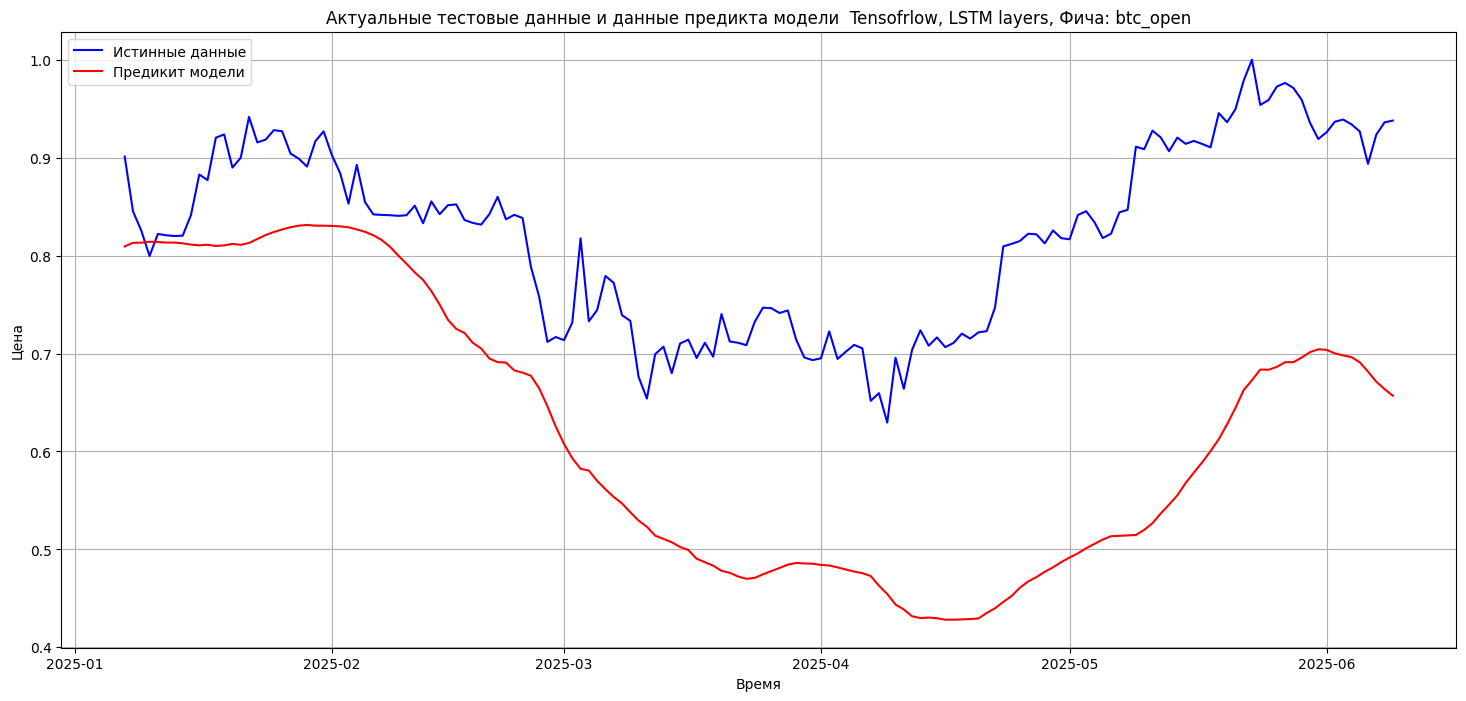

In [517]:
visual_actual_or_prediction(y_test['btc_open'], predict_frame['btc_open'], 'Tensofrlow', 'LSTM', 'btc_open' )

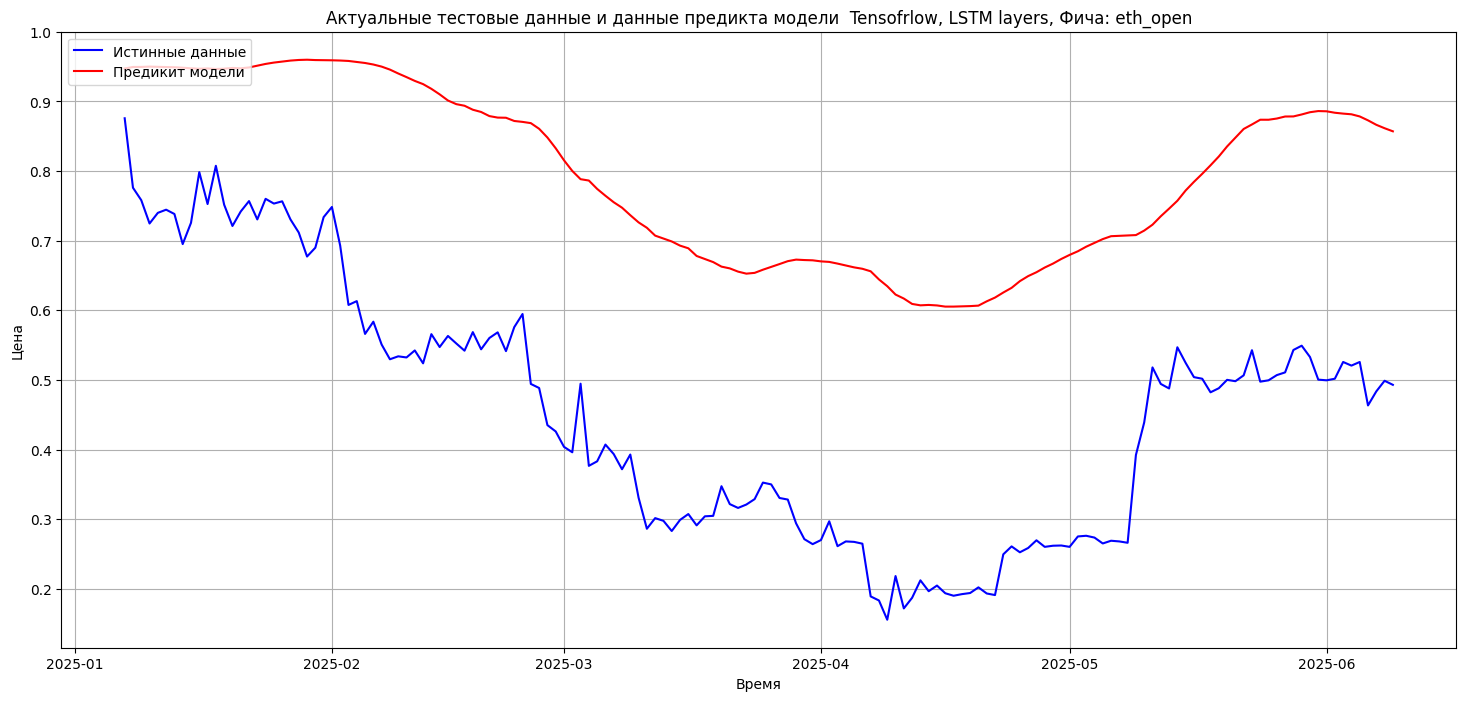

In [518]:
visual_actual_or_prediction(y_test['eth_open'], predict_frame['eth_open'], 'Tensofrlow', 'LSTM', 'eth_open' )

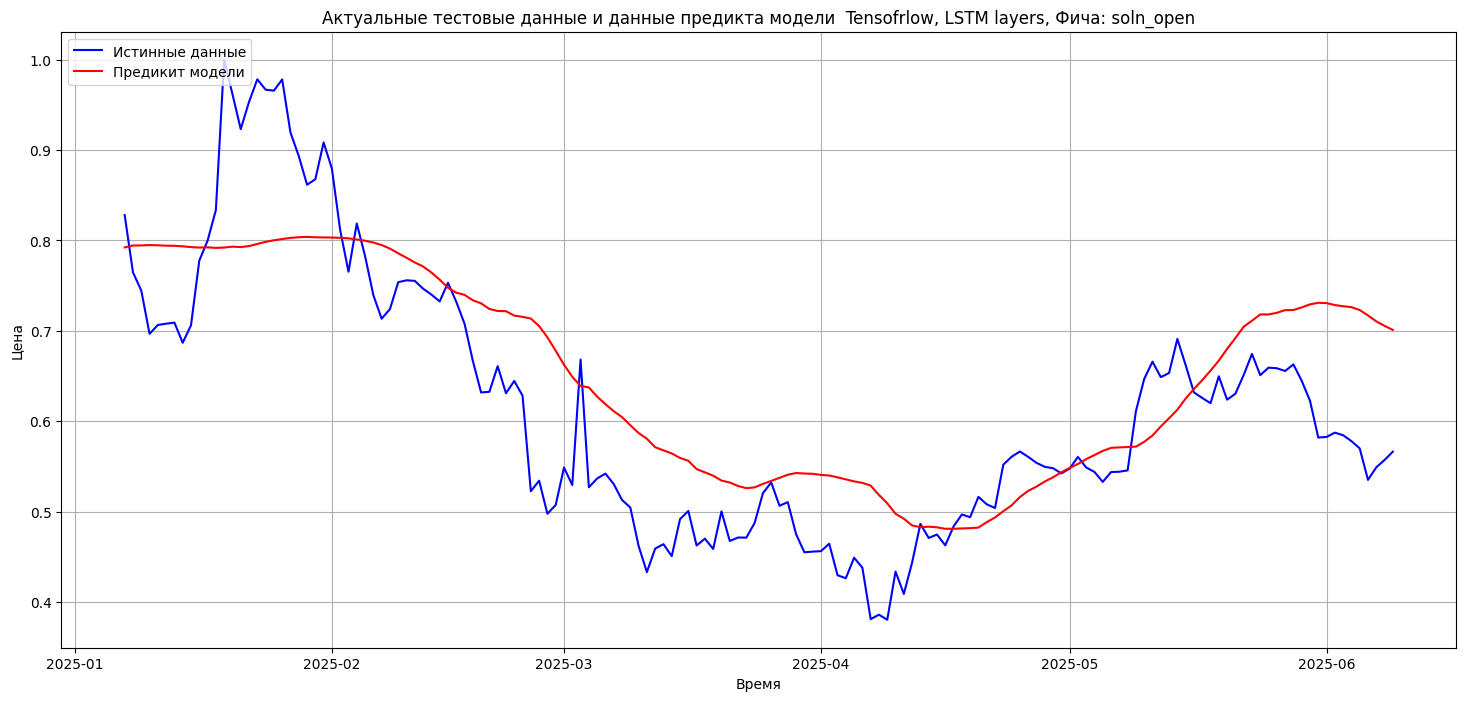

In [519]:
visual_actual_or_prediction(y_test['soln_open'], predict_frame['soln_open'], 'Tensofrlow', 'LSTM', 'soln_open' )

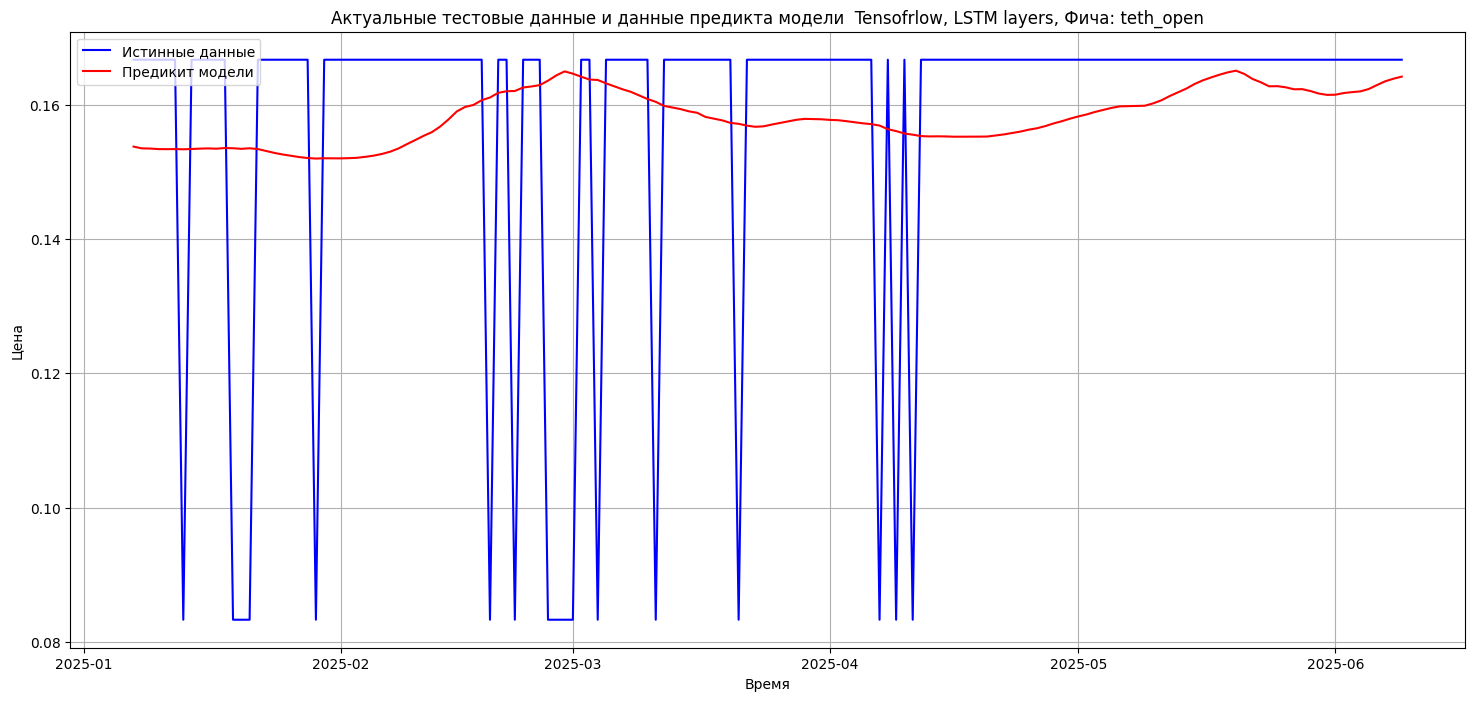

In [520]:
visual_actual_or_prediction(y_test['teth_open'], predict_frame['teth_open'], 'Tensofrlow', 'LSTM', 'teth_open' )

In [557]:
birge_2 = birge.copy()

In [558]:
date_idx = birge_2.columns[0]
birge_2 = birge_2.set_index(date_idx)

In [559]:
birge_2 = birge_2['btc_open']
birge_2 = birge_2.to_frame()

In [560]:
minmax = MinMaxScaler()
birge_2['btc_open'] = minmax.fit_transform(birge_2)

In [561]:
for col in birge_2.columns:
    for lags in range(1, 31):
        birge_2[f'{col}_lag{lags}'] = birge_2[col].shift(lags)

In [562]:
birge_2 = birge_2.fillna(0)

In [563]:
x_btc = birge_2.drop(columns = 'btc_open')
y_btc = birge_2['btc_open'].to_frame()

In [564]:
x_train_btc, x_test_btc = x_btc[:pri], x_btc[pri:]
y_train_btc, y_test_btc = y_btc[:pri], y_btc[pri:]

In [565]:
print(x_train_btc.shape)
print(y_train_btc.shape)
print(x_test_btc.shape)
print(y_test_btc.shape)

(929, 30)
(929, 1)
(167, 30)
(167, 1)


In [582]:
stopping_ = keras.callbacks.EarlyStopping(
        monitor="mae",
        patience=10,
        mode = 'auto',
        restore_best_weights=True,
        verbose = 1
        
    )
model_keras = keras.Sequential([
        keras.layers.Input(shape=(x_train_btc.shape[1],1)),
        keras.layers.LSTM(32),
        keras.layers.Dense(128,activation = 'relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation = 'relu', kernel_regularizer= 'l2'),
        keras.layers.Dense(1)
])
model_keras.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])



In [ ]:
history_keras_model = model_keras.fit(x_train_btc, y_train_btc, epochs = 100, batch_size = 32, 
        verbose = 1, callbacks = [stopping_])


In [585]:
predict_keras_btc= model_keras.predict(x_test_btc, verbose = 0)

In [586]:
mae1 = mean_absolute_error(y_test_btc,predict_keras_btc )
mae1

0.1729070246219635

In [609]:
predict_keras_btc.shape

(167, 1)

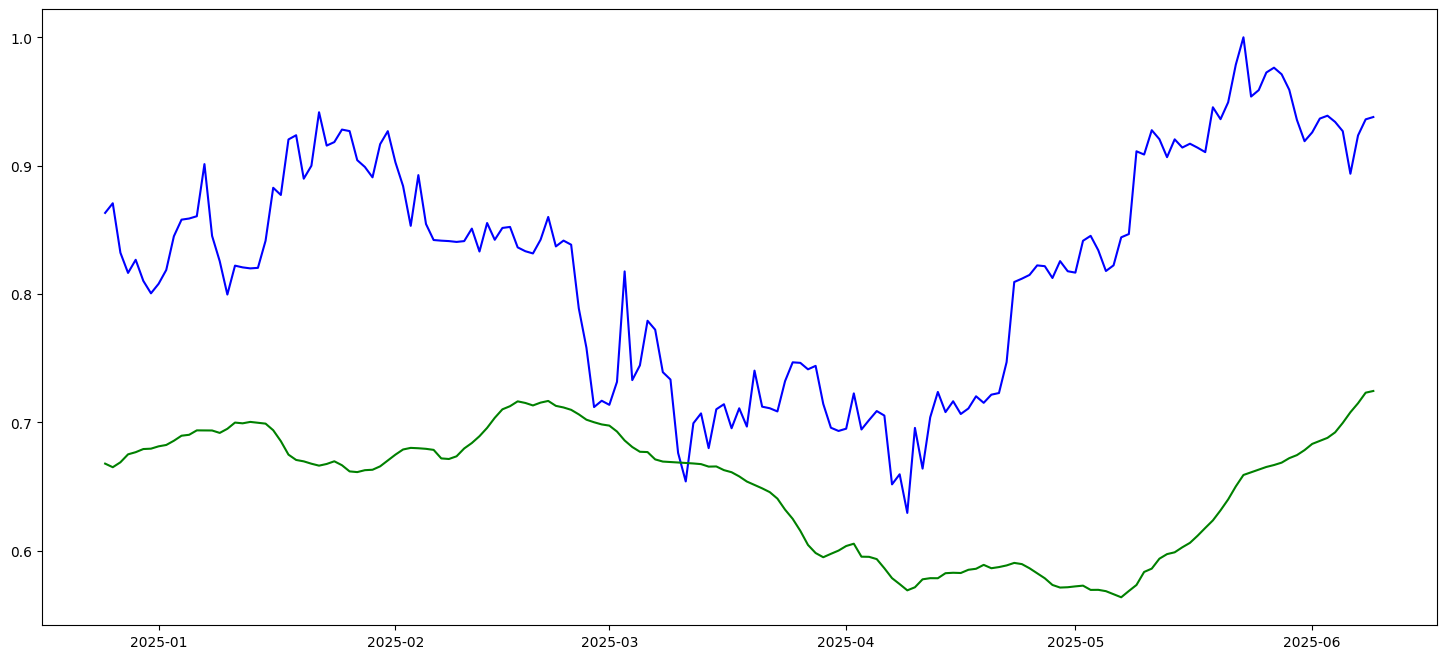

In [612]:
plt.figure(figsize = (18, 8))
plt.plot(y_test_btc.index, y_test_btc, 'b')
plt.plot(y_test_btc.index, predict_keras_btc, 'g')
plt.show()

In [720]:
model_keras_2 = keras.Sequential([
        keras.layers.Input(shape=(x_train_btc.shape[1],)),
        keras.layers.Dense(128,activation = 'relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation = 'relu', kernel_regularizer= 'l2'),
        keras.layers.Dense(32),
        keras.layers.Dense(1)
])
model_keras_2.compile(optimizer = 'adam', loss = 'mse', metrics = ['mae'])

In [ ]:
history_keras_model_2 = model_keras_2.fit(x_train_btc, y_train_btc, epochs = 100, batch_size = 32, 
        verbose = 1, callbacks = [stopping_])

In [781]:
predict_ker2 = model_keras_2.predict(x_test_btc)
mae_ker2 = mean_absolute_error(y_test_btc['btc_open'], predict_ker2)
mae

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


0.15800926089286804

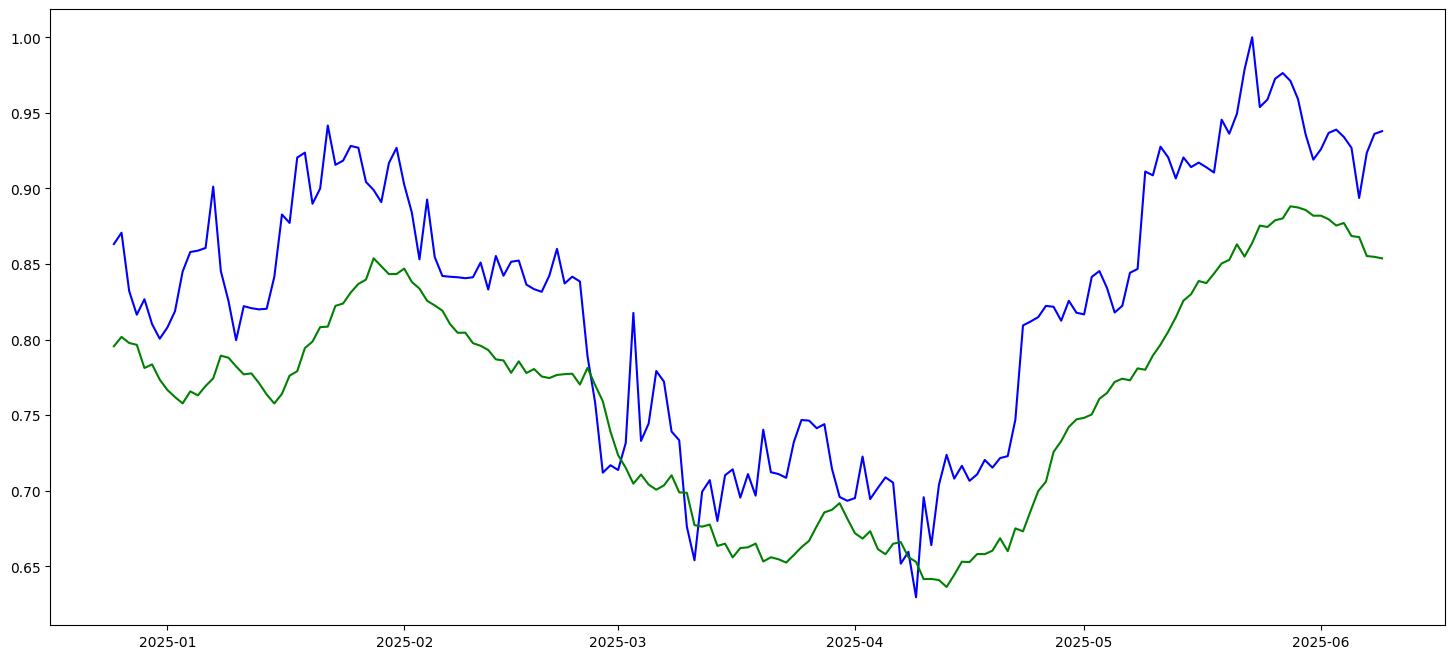

In [723]:
plt.figure(figsize = (18, 8))
plt.plot(y_test_btc.index, y_test_btc, 'b')
plt.plot(y_test_btc.index, predict_ker2, 'g')
plt.show()

In [787]:
last_test = y_btc.iloc[-30:].values[::-1] 
last_test = last_test.reshape(1,30).astype('float32')  

In [790]:
last_test.shape

(1, 30)

In [788]:
pred_yuli = []
days_to_predict = 6

for q in range(days_to_predict):
    pred = model_keras_2.predict(last_test)
    pred_value = pred.flatten()[0]
    pred_yuli.append(pred_value)
    last_test = np.append(last_test, pred_value)
    last_test = last_test[-30:]
    last_test = last_test.reshape(1, 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [831]:
pred_yuli

[np.float32(0.8497964),
 np.float32(0.854584),
 np.float32(0.86019844),
 np.float32(0.8583193),
 np.float32(0.8661967),
 np.float32(0.8671658)]

In [816]:
predict_last = np.array(pred_yuli)

In [810]:
new_index = pd.date_range('2025-06-10', '2025-06-15', freq = 'd')

In [838]:
y_btc.values[-1][0]

np.float64(0.9378732200275608)

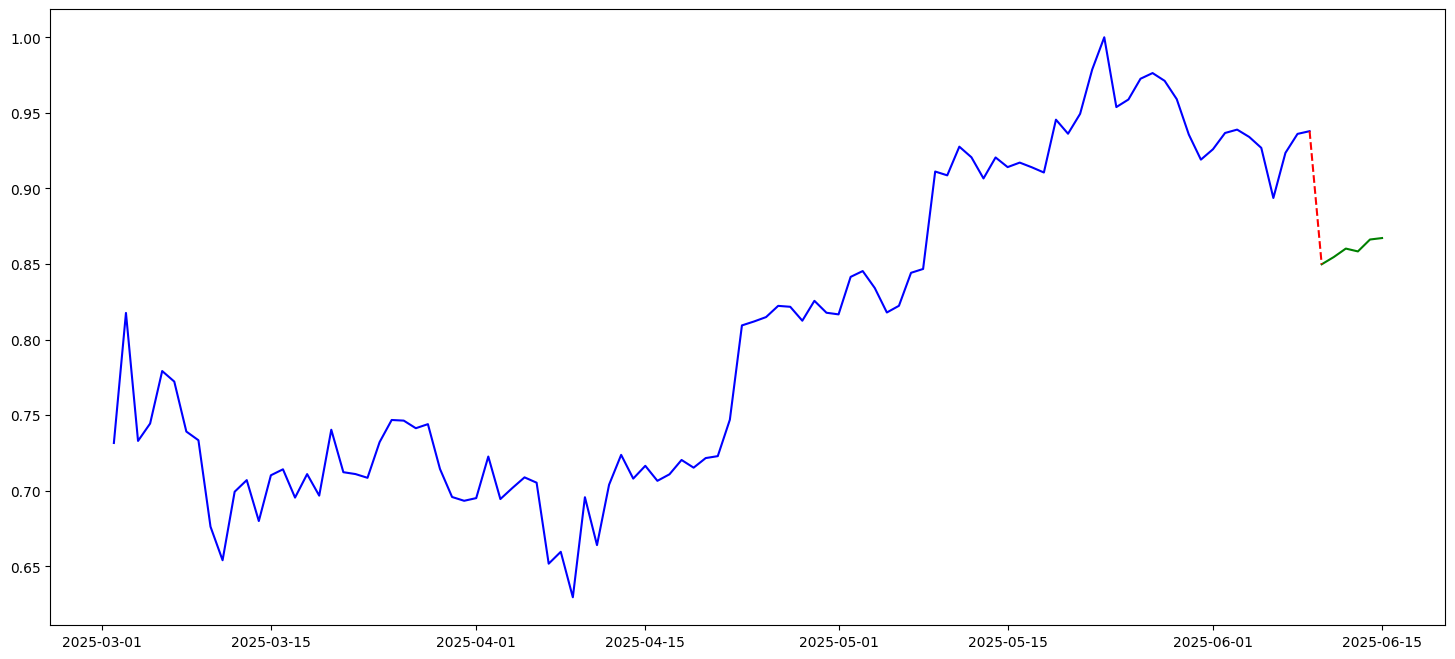

In [840]:
plt.figure(figsize = (18, 8))
plt.plot(y_btc.index[-100:], y_btc[-100:], 'b')
plt.plot(new_index, pred_yuli, 'g')
plt.plot([y_btc.index[-1], new_index[0]], 
          [y_btc.values[-1][0],pred_yuli[0]] , 'r--')
plt.show()